In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.datasets import make_blobs
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_digits

import seaborn as sns
sns.set()

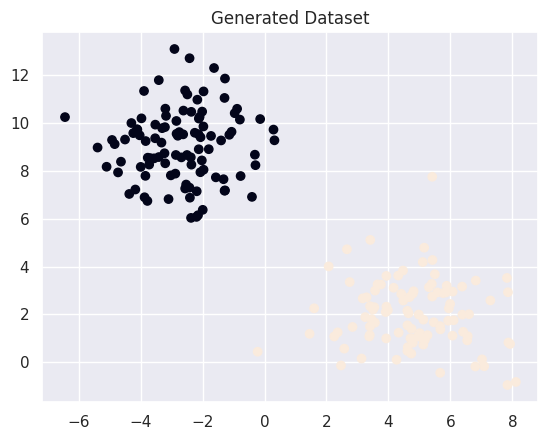

In [2]:
X, Y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)

plt.scatter(X[:,0], X[:,1], c=Y)
plt.title("Generated Dataset")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [4]:
clf = svm.SVC(kernel='linear', C=1)

clf.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [5]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [6]:
print("Support Vectors:")

print(clf.support_vectors_)

Support Vectors:
[[-0.40500616  6.91150953]
 [ 2.65952903  4.72035783]
 [ 2.07017704  4.00397825]]


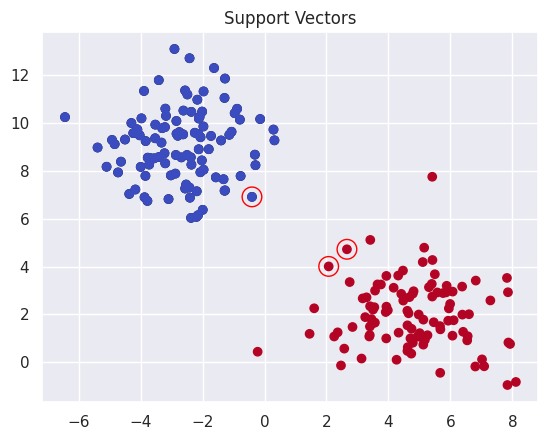

In [7]:
plt.scatter(X[:,0], X[:,1], c=Y)
plt.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm')

plt.scatter(clf.support_vectors_[:,0],
            clf.support_vectors_[:,1],
            s=200,
            facecolors='none',
            edgecolors='red')

plt.title("Support Vectors")
plt.show()

In [8]:
w = clf.coef_[0]
b = clf.intercept_[0]

print("Weight Vector:", w)
print("Bias:", b)

norm = np.linalg.norm(w)

print("Norm of weight vector:", norm)

Weight Vector: [ 0.4110133  -0.33792047]
Bias: 1.502054358120785
Norm of weight vector: 0.5320922625649595


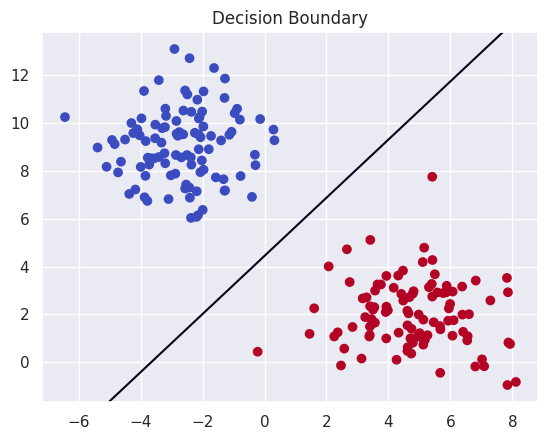

In [9]:
def plot_decision_boundary(model,X,Y):

    plt.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)

    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0])

    plt.title("Decision Boundary")
    plt.show()

plot_decision_boundary(clf,X,Y)

In [10]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print("Feature Shape:", X.shape)
print("Labels:", cancer.target_names)

Feature Shape: (569, 30)
Labels: ['malignant' 'benign']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [12]:
clf = svm.SVC(kernel='linear')

clf.fit(X_train,y_train)

SVC(kernel='linear')

In [13]:
y_pred = clf.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))

Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465


In [15]:
kernels = ['linear','poly','rbf']

for k in kernels:

    model = svm.SVC(kernel=k)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print("Kernel:",k)
    print("Accuracy:", accuracy_score(y_test,pred))
    print("Precision:", precision_score(y_test,pred))
    print("Recall:", recall_score(y_test,pred))
    print()

Kernel: linear
Accuracy: 0.956140350877193
Precision: 0.9459459459459459
Recall: 0.9859154929577465

Kernel: poly
Accuracy: 0.9473684210526315
Precision: 0.922077922077922
Recall: 1.0

Kernel: rbf
Accuracy: 0.9473684210526315
Precision: 0.922077922077922
Recall: 1.0



In [16]:
C_values = [0.1,1,10,100]

for c in C_values:

    model = svm.SVC(kernel='linear',C=c)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print("C:",c,"Accuracy:",accuracy_score(y_test,pred))

C: 0.1 Accuracy: 0.9649122807017544
C: 1 Accuracy: 0.956140350877193
C: 10 Accuracy: 0.956140350877193
C: 100 Accuracy: 0.956140350877193


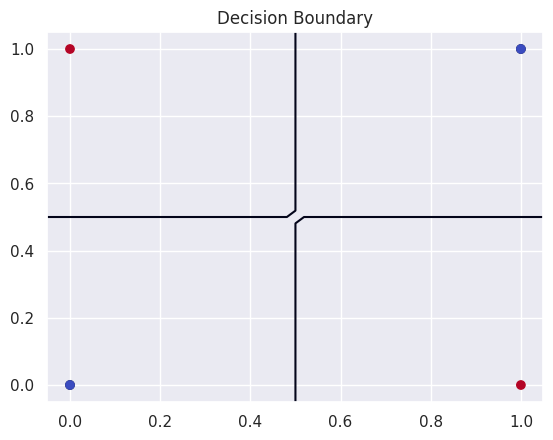

In [17]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

model = svm.SVC(kernel='rbf')

model.fit(X,y)

plt.scatter(X[:,0],X[:,1],c=y)

plot_decision_boundary(model,X,y)

In [18]:
from sklearn.metrics.pairwise import rbf_kernel

X = np.array([
    [1,2],
    [5,5],
    [2,1],
    [4,4]
])

kernel_matrix = rbf_kernel(X)

print("Kernel Matrix:\n")
print(kernel_matrix)

Kernel Matrix:

[[1.00000000e+00 3.72665317e-06 3.67879441e-01 1.50343919e-03]
 [3.72665317e-06 1.00000000e+00 3.72665317e-06 3.67879441e-01]
 [3.67879441e-01 3.72665317e-06 1.00000000e+00 1.50343919e-03]
 [1.50343919e-03 3.67879441e-01 1.50343919e-03 1.00000000e+00]]


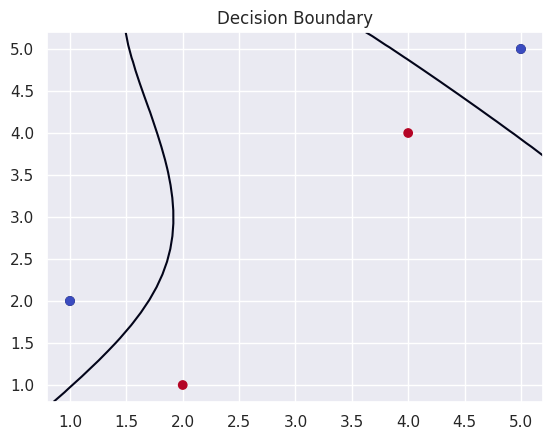

In [19]:
y = np.array([-1,-1,1,1])

model = svm.SVC(kernel='rbf')

model.fit(X,y)

plt.scatter(X[:,0],X[:,1],c=y)

plot_decision_boundary(model,X,y)

In [20]:
digits = load_digits()

X = digits.data
y = digits.target

In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [22]:
kernels = ['linear','poly','rbf']

for k in kernels:

    model = svm.SVC(kernel=k)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    print("Kernel:",k)

    print("Accuracy:",accuracy_score(y_test,pred))

Kernel: linear
Accuracy: 0.9777777777777777
Kernel: poly
Accuracy: 0.9916666666666667
Kernel: rbf
Accuracy: 0.9861111111111112


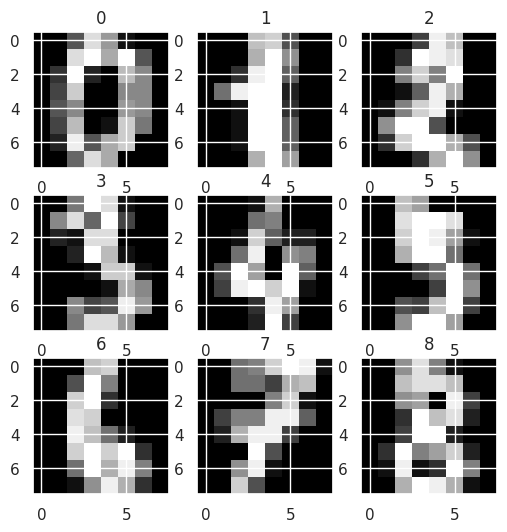

In [23]:
plt.figure(figsize=(6,6))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(digits.images[i], cmap='gray')

    plt.title(digits.target[i])

plt.show()

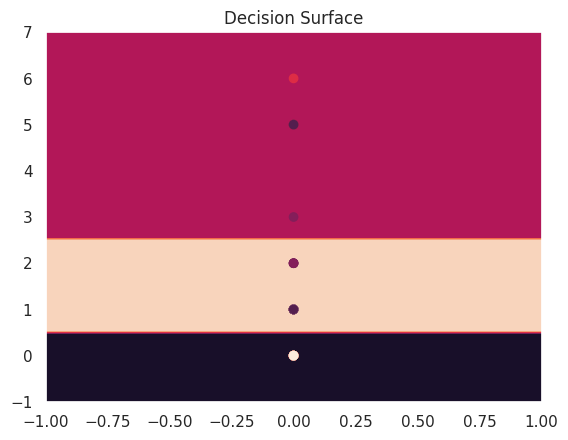

In [24]:
from sklearn.inspection import DecisionBoundaryDisplay

model = svm.SVC(kernel='linear')

# Train the model using only the first two features for visualization purposes
model.fit(X_train[:200, :2], y_train[:200])

# Plot the decision boundary using only the first two features
DecisionBoundaryDisplay.from_estimator(
    model,
    X_train[:200, :2],
    response_method="predict",
)

# Plot the data points using only the first two features
plt.scatter(X_train[:200, 0], X_train[:200, 1], c=y_train[:200])

plt.title("Decision Surface")

plt.show()